# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Objective
Predict whether a bank customer will subscribe to a term deposit based on marketing campaign data, using classification models, and explain the predictions using SHAP.

## Dataset
Bank Marketing Dataset (UCI Machine Learning Repository)

## 1. Data Loading
Downloading and extracting the Bank Marketing dataset from the UCI repository.

In [2]:
!wget -q https://archive.ics.uci.edu/static/public/222/bank+marketing.zip -O bank.zip

In [3]:
!unzip -o bank.zip -d bank_data

Archive:  bank.zip
 extracting: bank_data/bank.zip      
 extracting: bank_data/bank-additional.zip  


In [4]:
!unzip -o bank_data/bank.zip -d bank_data

Archive:  bank_data/bank.zip
  inflating: bank_data/bank-full.csv  
  inflating: bank_data/bank-names.txt  
  inflating: bank_data/bank.csv      


In [5]:
!ls bank_data

bank-additional.zip  bank.csv  bank-full.csv  bank-names.txt  bank.zip


In [6]:
import pandas as pd
df = pd.read_csv("bank_data/bank-full.csv", sep=';')
df.shape

(45211, 17)

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Exploratory Data Analysis (EDA)
Exploring the dataset structure, checking for missing values, understanding feature distributions, and examining the target variable.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [10]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


### 2.1 Target Variable Visualization

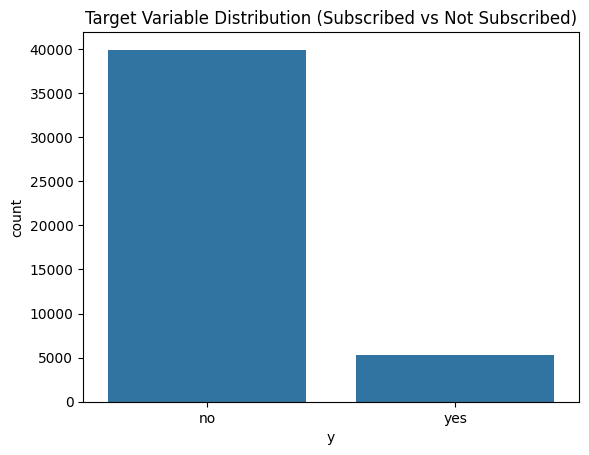

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution (Subscribed vs Not Subscribed)')
plt.show()

### 2.2 Numeric Feature Distributions

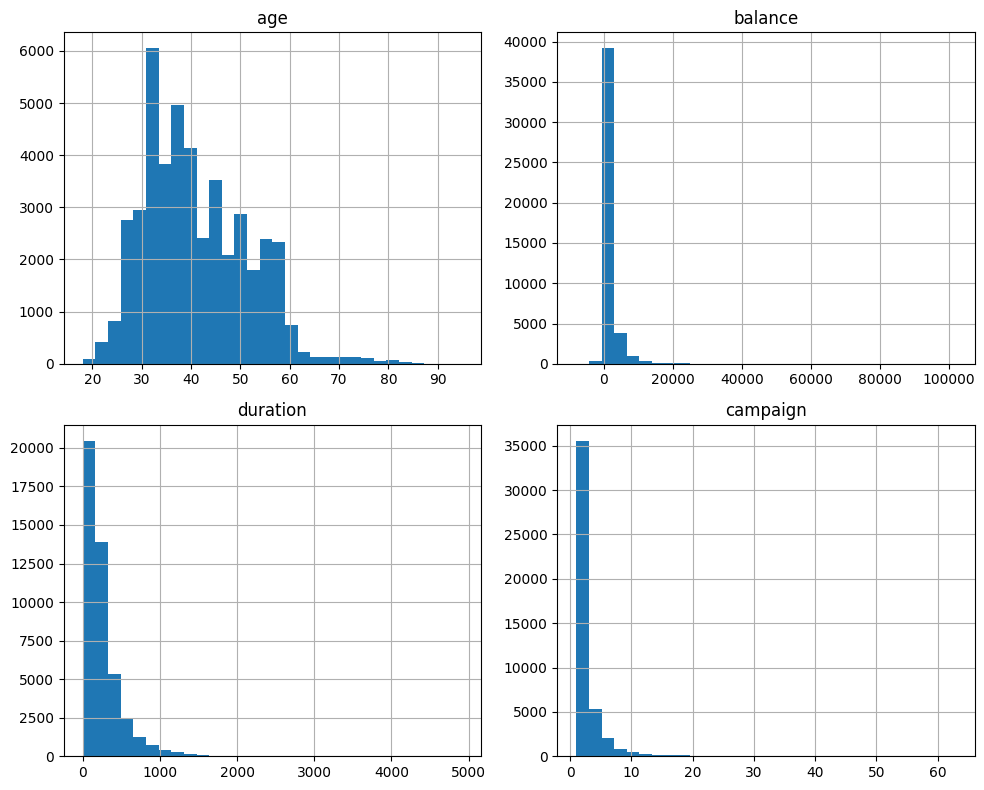

In [12]:
df[['age', 'balance', 'duration', 'campaign']].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

### 2.3 Categorical Feature vs Target

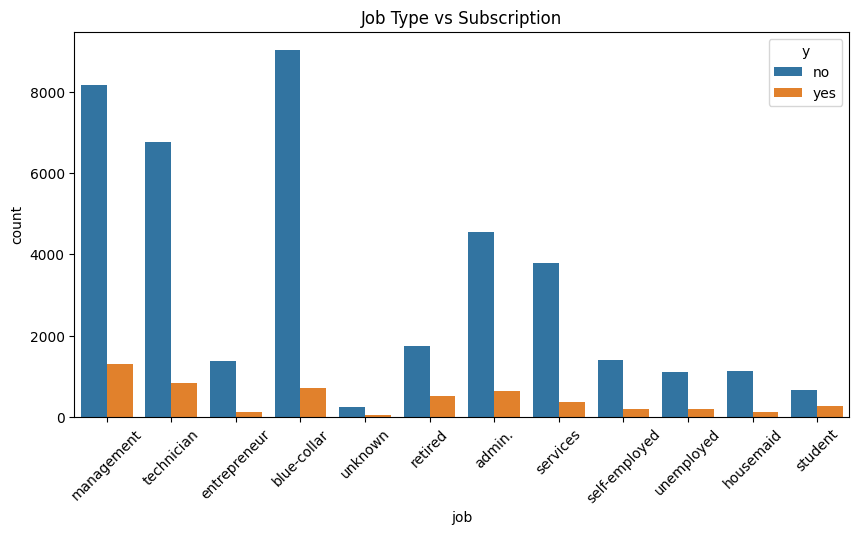

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Job Type vs Subscription')
plt.show()

## 3. Data Preprocessing & Feature Encoding
Encoding categorical variables and preparing the target column for modeling.

In [14]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df['y'].value_counts()

,count
y,
0,39922
1,5289


In [15]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [16]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.shape

(45211, 43)

In [17]:
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True


## 4. Train-Test Split
Splitting the data into training and testing sets for model evaluation.

In [18]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']
X.shape, y.shape

((45211, 42), (45211,))

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((36168, 42), (9043, 42))

## 5. Model Training
Training Logistic Regression and Random Forest classifiers.

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
print("Logistic Regression trained successfully")

Logistic Regression trained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


## 6. Model Evaluation
Evaluating both models using Confusion Matrix, F1-Score, and ROC Curve.

In [22]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

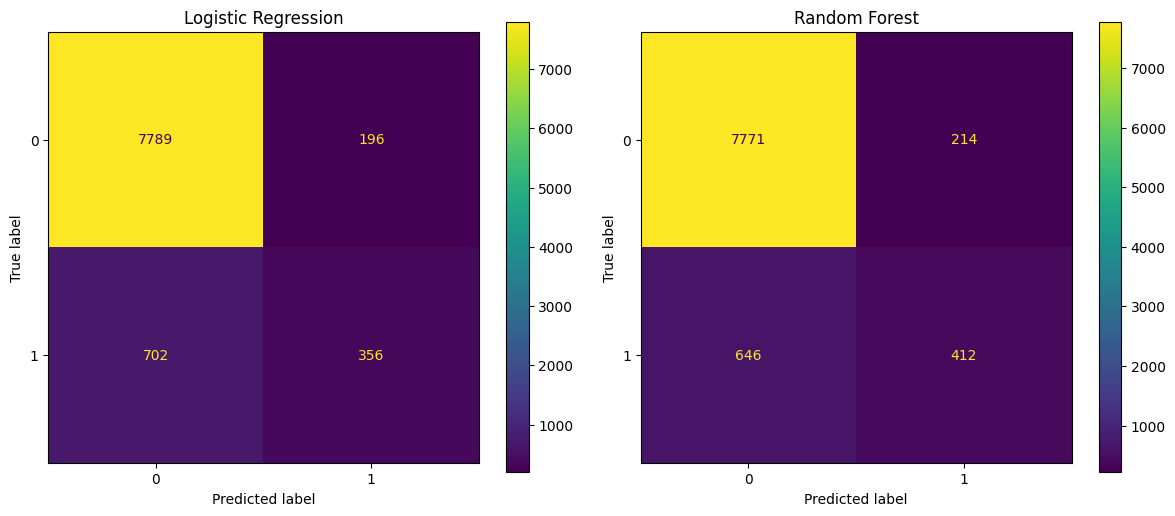

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0])
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import f1_score, classification_report

print("Logistic Regression F1-Score:", f1_score(y_test, y_pred_log))
print("Random Forest F1-Score:", f1_score(y_test, y_pred_rf))

print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression F1-Score: 0.4422360248447205
Random Forest F1-Score: 0.48931116389548696

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.64      0.34      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.69      9043
weighted avg       0.89      0.90      0.89      9043


Random Forest Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



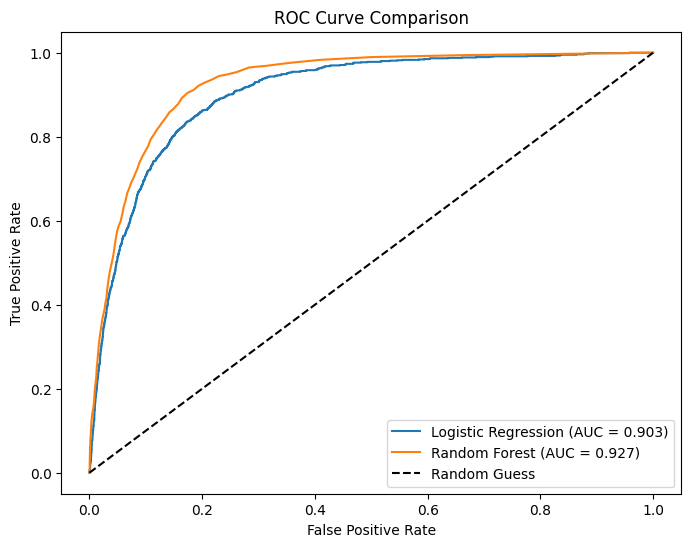

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 7. Model Explainability with SHAP
Using SHAP to explain individual predictions from the Random Forest model (best performing model).

In [26]:
!pip install shap -q
import shap

In [27]:
X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

### 7.1 Overall Feature Importance (SHAP Summary Plot)

In [29]:
import numpy as np
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(100, 42, 2)


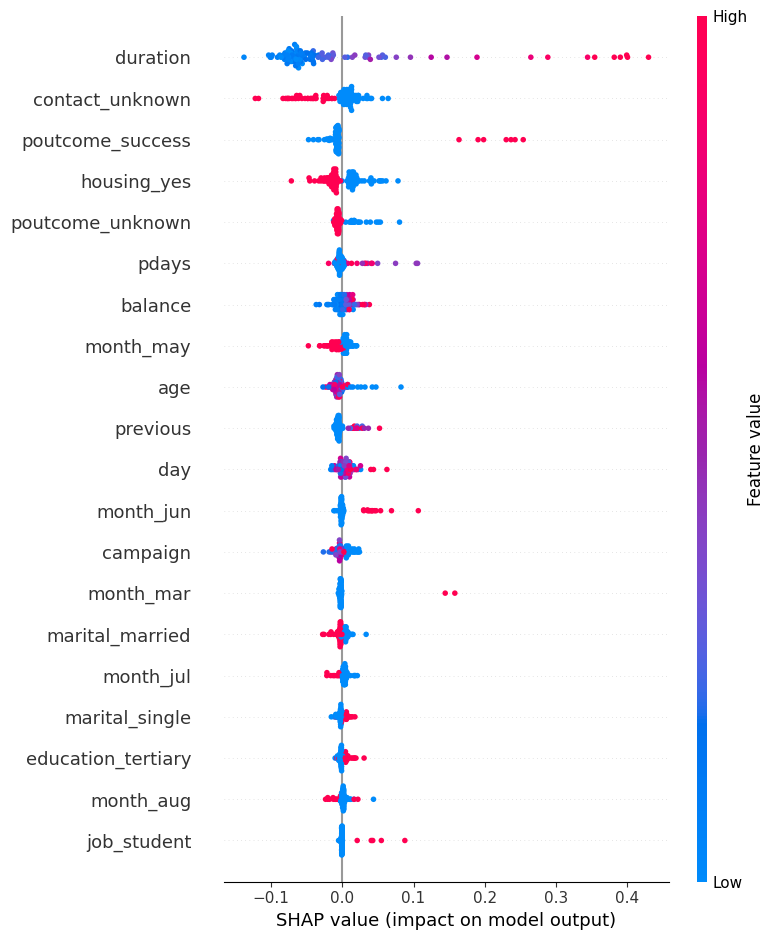

In [30]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

### 7.2 Individual Prediction Explanations
Explaining 5 individual predictions to understand model decision-making.

--- Customer 1 ---
Actual: 0 | Predicted: 0


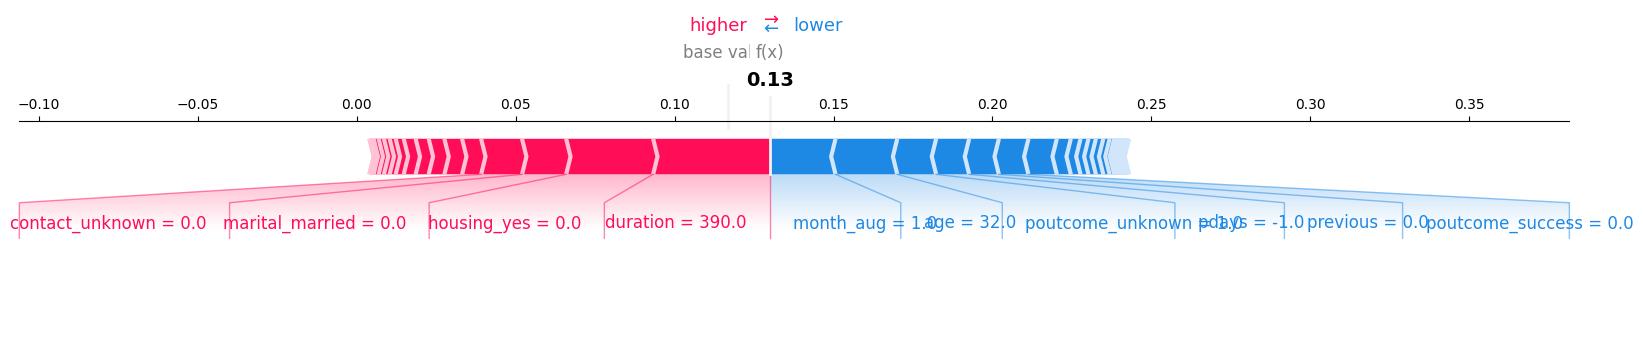

--- Customer 2 ---
Actual: 0 | Predicted: 0


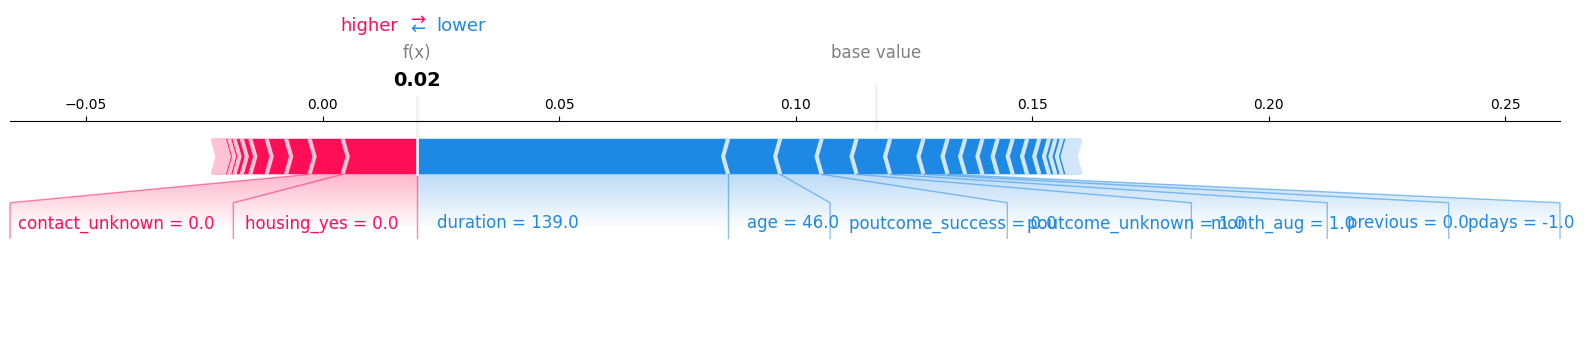

--- Customer 3 ---
Actual: 1 | Predicted: 1


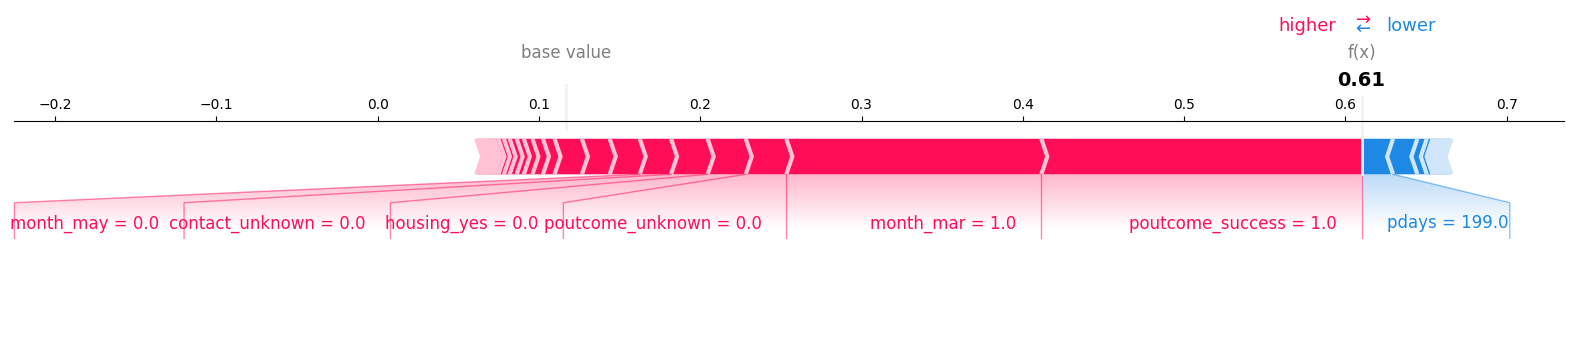

--- Customer 4 ---
Actual: 0 | Predicted: 0


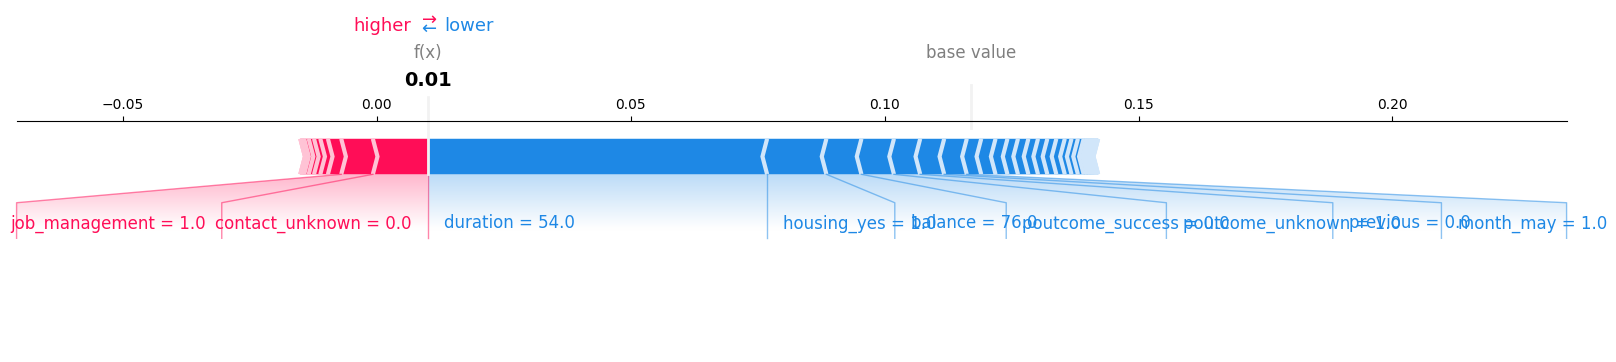

--- Customer 5 ---
Actual: 0 | Predicted: 0


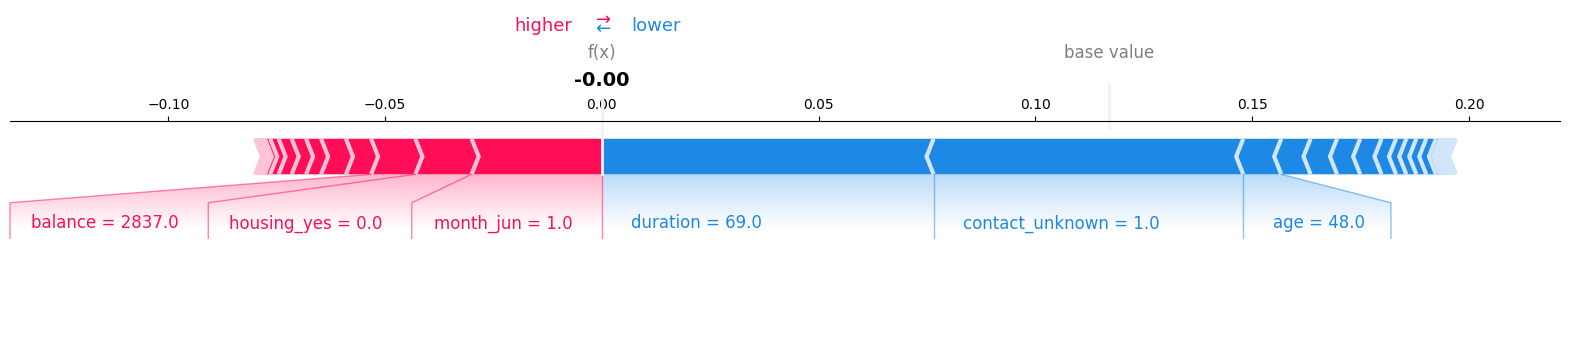

In [31]:
for i in range(5):
    print(f"--- Customer {i+1} ---")
    actual = y_test.loc[X_sample.index[i]]
    predicted = rf_model.predict(X_sample.iloc[[i]])[0]
    print("Actual:", actual, "| Predicted:", predicted)

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[i, :, 1],
        X_sample.iloc[i],
        matplotlib=True
    )
    plt.show()

## 8. Conclusion

### Key Findings:
- The dataset is highly imbalanced (only ~12% of customers subscribed to a term deposit), making F1-Score and ROC-AUC more reliable metrics than accuracy.
- Random Forest outperformed Logistic Regression on both F1-Score (0.49 vs 0.44) and AUC (0.927 vs 0.903).
- SHAP analysis revealed that features like `duration` (call duration), `balance`, and `poutcome` (previous campaign outcome) were among the most influential in predicting subscription likelihood.
- Both models struggled with recall for the minority class (subscribers), indicating room for improvement through techniques like SMOTE, class weighting, or threshold tuning.

### Future Improvements:
- Apply class balancing techniques (SMOTE, class_weight='balanced')
- Hyperparameter tuning using GridSearchCV
- Try additional models like XGBoost or LightGBM